# Tied-diagonal-block (pooled) vs dense (no pooling) MIMO

Concrete prototype of the two structures discussed in `wiki/concepts/MarketIntradayMomentum.md`:

- **Pooled tied-diagonal-block** — build **one shared 5→1 TIB block** (`m` poles + 5-feature null vectors), run *every* instrument's features through it to get states, and fit **one shared `C`** on the concatenated panel. This is the block-diagonal MIMO with *identical, tied* blocks (own-asset only, pooled).
- **Dense, no pooling** — each output reads **all** instruments' states (`25·m`) via its **own** `C` row, fit independently per output. The full 125→25 MIMO with no tying.

> **Synthetic.** To isolate the `C`-estimation/pooling effect, the *same* shared block `(A_b, B_b)` is used to generate the data and by the estimators — so only the `C` structure differs. Numbers are illustrative.

In [1]:
%matplotlib inline
import sys, os
try:
    import ga  # noqa
except ModuleNotFoundError:
    sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), "..")))

import numpy as np
import matplotlib.pyplot as plt
from ga.filters.tib import poles_chebyshev_roots, null_basis_realization

rng = np.random.default_rng(0)

## One shared block + synthetic 25-instrument panel

The shared block is a 5-feature → `m`-state TIB. Each instrument's 5 feature series are filtered through the *same* `(A_b, B_b)` to give its state sequence. In **Scenario A** the truth is **diagonal + tied**: every instrument's return is the *same* filter `c_true` of its *own* states, plus heavy noise (low SNR).

In [2]:
N_INST, F, M = 25, 5, 5            # instruments, features, poles (timescales)
T, NTR_FULL = 4000, 3000           # total days; full training size (test = last 1000)
R2_POP = 0.04                      # population R^2 (realistic, low SNR)

# --- one shared block: m poles + 5-feature null vectors ---
poles = poles_chebyshev_roots(M)
Vb = rng.standard_normal((F, M)); Vb /= np.linalg.norm(Vb, axis=0)
blk = null_basis_realization(poles, Vb)
Ab, Bb = blk.A(dense=True).real, blk.B(dense=True).real     # (M,M), (M,F)
c_true = rng.standard_normal(M)                             # the shared own-asset filter

def run_states(A, B, U):
    """Causal states: X[t] uses inputs up to t-1 (no look-ahead)."""
    T, m = U.shape[0], A.shape[0]
    X = np.zeros((T, m)); x = np.zeros(m)
    for t in range(T):
        X[t] = x; x = A @ x + B @ U[t]
    return X

U   = [rng.standard_normal((T, F)) for _ in range(N_INST)]
X   = [run_states(Ab, Bb, Ui) for Ui in U]                 # per-instrument states (T, M)
Xall = np.hstack(X)                                        # global state (T, N_INST*M)
own_sig = [Xi @ c_true for Xi in X]
sigma = np.sqrt(np.mean([np.var(s) for s in own_sig]) * (1 - R2_POP) / R2_POP)
y = [s + sigma * rng.standard_normal(T) for s in own_sig]  # Scenario A: diagonal + tied

print(f"{N_INST} instruments, {F} features, {M} poles, T={T}, population R^2={R2_POP:.0%}")
print(f"free params:  pooled={M}   unpooled={N_INST*M}   dense={N_INST*N_INST*M}")

25 instruments, 5 features, 5 poles, T=4000, population R^2=4%
free params:  pooled=5   unpooled=125   dense=3125


## Estimators

All linear least squares (per-instrument demeaning; OOS benchmark = training mean).
- **pooled** — one `c` from the stacked panel (`25·T` rows, `M` params).
- **unpooled** — separate `c_i` per instrument (same own-asset structure, *not* tied).
- **dense** — per output, a full `c` over *all* `25·M` states (no pooling).

In [3]:
def pooled(Xtr, ytr, Xte):
    xbs = [x.mean(0) for x in Xtr]; ybs = [yy.mean() for yy in ytr]
    Phi = np.vstack([x - xb for x, xb in zip(Xtr, xbs)])
    yv  = np.concatenate([yy - yb for yy, yb in zip(ytr, ybs)])
    c, *_ = np.linalg.lstsq(Phi, yv, rcond=None)
    preds = [yb + (xe - xb) @ c for xe, xb, yb in zip(Xte, xbs, ybs)]
    return preds, ybs, c

def unpooled(Xtr, ytr, Xte):
    preds, ybs = [], []
    for xtr, yt, xte in zip(Xtr, ytr, Xte):
        xb, yb = xtr.mean(0), yt.mean(); ybs.append(yb)
        c, *_ = np.linalg.lstsq(xtr - xb, yt - yb, rcond=None)
        preds.append(yb + (xte - xb) @ c)
    return preds, ybs

def dense(Xall_tr, ytr, Xall_te):
    xb = Xall_tr.mean(0); preds, ybs = [], []
    for yt in ytr:
        yb = yt.mean(); ybs.append(yb)
        c, *_ = np.linalg.lstsq(Xall_tr - xb, yt - yb, rcond=None)   # full 25*M weights
        preds.append(yb + (Xall_te - xb) @ c)
    return preds, ybs

def oos_r2(yte, preds, ybs):
    return float(np.mean([1 - np.sum((yt - pr)**2) / np.sum((yt - yb)**2)
                          for yt, pr, yb in zip(yte, preds, ybs)]))

def split(arr_list, ntr): return [a[:ntr] for a in arr_list], [a[ntr:T] for a in arr_list]

def evaluate(ntr, yv):
    Xtr, Xte = split(X, ntr); ytr, yte = split(yv, ntr)
    p_pred, p_yb, c_hat = pooled(Xtr, ytr, Xte)
    u_pred, u_yb        = unpooled(Xtr, ytr, Xte)
    d_pred, d_yb        = dense(Xall[:ntr], ytr, Xall[ntr:T])
    return dict(pooled=oos_r2(yte, p_pred, p_yb),
                unpooled=oos_r2(yte, u_pred, u_yb),
                dense=oos_r2(yte, d_pred, d_yb)), c_hat

## Scenario A — truth is diagonal + tied (pooling should win)

avg OOS R^2 over 25 instruments (train = 3000):
  pooled     0.0411
  unpooled   0.0396
  dense     -0.0098


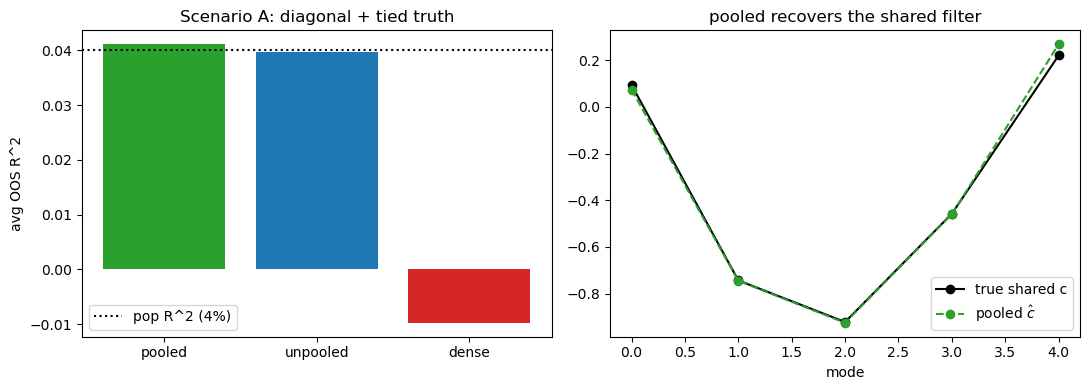

In [4]:
resA, c_hat = evaluate(NTR_FULL, y)
print("avg OOS R^2 over 25 instruments (train = 3000):")
for k, v in resA.items():
    print(f"  {k:<9}{v:>8.4f}")

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].bar(list(resA), list(resA.values()), color=["C2", "C0", "C3"])
ax[0].axhline(R2_POP, color="k", ls=":", label=f"pop R^2 ({R2_POP:.0%})")
ax[0].set_ylabel("avg OOS R^2"); ax[0].set_title("Scenario A: diagonal + tied truth"); ax[0].legend()
ax[1].plot(c_true, "k-o", label="true shared c")
ax[1].plot(c_hat, "C2--o", label=r"pooled $\hat c$")
ax[1].set_title("pooled recovers the shared filter"); ax[1].set_xlabel("mode"); ax[1].legend()
fig.tight_layout(); plt.show()

### Sample-size sweep

The dense model has `25·M` weights *per output*; with little data it fits noise (OOS R² can go negative). The pooled model has `M` shared weights estimated from `25×` the data — robust throughout.

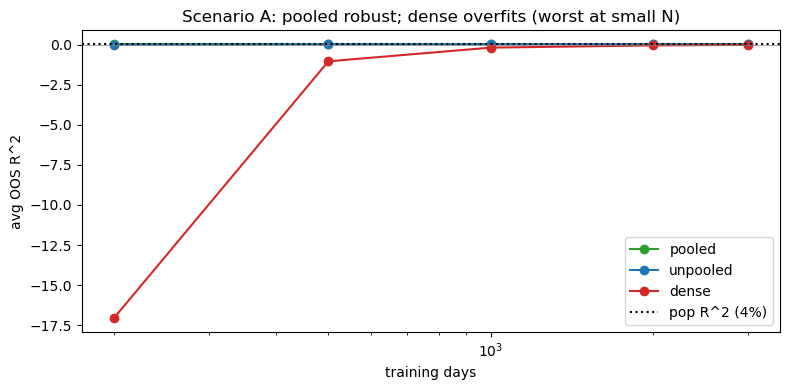

pooled    [0.0392, 0.0401, 0.0406, 0.0411, 0.0411]
unpooled  [0.0051, 0.0312, 0.0365, 0.0387, 0.0396]
dense     [-17.0807, -1.0363, -0.1815, -0.0463, -0.0098]


In [5]:
sizes = [200, 500, 1000, 2000, 3000]
curves = {k: [] for k in ("pooled", "unpooled", "dense")}
for ntr in sizes:
    r, _ = evaluate(ntr, y)
    for k in curves: curves[k].append(r[k])

fig, ax = plt.subplots(figsize=(8, 4))
for k, col in zip(curves, ["C2", "C0", "C3"]):
    ax.plot(sizes, curves[k], "-o", color=col, label=k)
ax.axhline(R2_POP, color="k", ls=":", label=f"pop R^2 ({R2_POP:.0%})")
ax.axhline(0, color="grey", lw=0.5)
ax.set_xscale("log"); ax.set_xlabel("training days"); ax.set_ylabel("avg OOS R^2")
ax.set_title("Scenario A: pooled robust; dense overfits (worst at small N)"); ax.legend()
fig.tight_layout(); plt.show()
for k in curves: print(f"{k:<9}", [round(v, 4) for v in curves[k]])

## Scenario B — the honest counterpoint: real cross-asset signal

Now each instrument's return *also* loads on its **neighbour's** filtered states — a genuine lead-lag term the diagonal (pooled/unpooled) models structurally cannot see, but the dense model can. Does that flexibility pay off at this SNR?

In [6]:
GAMMA = 0.7
cross_sig = [GAMMA * (X[(i - 1) % N_INST] @ c_true) for i in range(N_INST)]   # lead-lag
yB = [own_sig[i] + cross_sig[i] + sigma * rng.standard_normal(T) for i in range(N_INST)]

resB, _ = evaluate(NTR_FULL, yB)
print("Scenario B (own + lead-lag neighbour) — avg OOS R^2 (train = 3000):")
for k, v in resB.items():
    print(f"  {k:<9}{v:>8.4f}")
print(f"\n-> dense OOS R^2 rose from {resA['dense']:.4f} (Scenario A) to {resB['dense']:.4f}: it DID")
print("   capture some of the lead-lag the diagonal models structurally miss.")
print(f"-> but dense ({resB['dense']:.4f}) still LOSES to pooled ({resB['pooled']:.4f}): the own-asset")
print("   part dominates and a dense 25*M-weight fit pays too much variance.")
print("-> lesson: harvest cross-asset signal with a small REGULARIZED / low-rank factor block, not dense.")

Scenario B (own + lead-lag neighbour) — avg OOS R^2 (train = 3000):
  pooled     0.0433
  unpooled   0.0414
  dense      0.0123

-> dense OOS R^2 rose from -0.0098 (Scenario A) to 0.0123: it DID
   capture some of the lead-lag the diagonal models structurally miss.
-> but dense (0.0123) still LOSES to pooled (0.0433): the own-asset
   part dominates and a dense 25*M-weight fit pays too much variance.
-> lesson: harvest cross-asset signal with a small REGULARIZED / low-rank factor block, not dense.


## Conclusions

- **Scenario A (diagonal + tied truth):** the **pooled tied-block** model dominates — it estimates `M` shared weights from `25×` the data, hitting the population R². The **dense** model spends `25·M` weights per output on cross-asset states that are *truly zero* → it overfits, worst at small `N` (OOS R² can go **negative**). Pooling buys variance reduction = structure + data.
- **Scenario B (real cross-asset signal):** the dense model's OOS R² *rises* (it does capture some of the lead-lag the diagonal models structurally miss) — but it **still loses to pooled**, because the own-asset part dominates and a dense `25·M`-weight fit pays too much variance. Even *with* genuine cross-asset signal, dense isn't worth it here.
- **The takeaway:** at return SNR the **pooled diagonal** backbone is the robust core; harvest cross-asset signal with a **small, regularized / low-rank factor block** that earns its keep OOS — **not** a dense full MIMO (which loses even when the cross-asset signal is real).
- *Construction recap:* the pooled model is literally **one shared block → states per instrument → one pooled `C`** (you never build the big block-diagonal matrix); the dense model is each output reading all states with its own `C`.